In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [4]:
df = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_finished_cat_11.csv').drop('Unnamed: 0',axis=1)
df

,Rndrng_NPI,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,pca_1,...,PharmacyNutrition_Tot_Risk_2,PharmacyNutrition_Tot_Risk_0,PharmacyNutrition_Tot_Risk_1,state_South,state_Midwest,state_Northeast,state_West,state_Territory,state_Military,state_Unknown
0,1003000126,22,665,1648.0,395335.0,146521.84,116332.66,74,2.1114,0.047429,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1003000134,13,3939,7517.0,1211425.0,282079.49,217960.62,76,1.0156,0.411904,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1003000142,42,144,661.0,197224.0,63334.30,49752.77,63,1.5662,-0.096087,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1003000407,37,436,1683.0,240818.0,174786.95,138741.21,76,1.8967,0.037454,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1003000423,33,63,320.0,31637.0,13176.47,10320.43,56,1.1882,-0.194836,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196593,1992999551,26,230,1103.0,145838.0,86140.00,61178.65,77,1.0393,-0.084730,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196594,1992999569,4,15,25.0,3660.0,3159.02,2302.62,73,0.7647,-0.213209,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196595,1992999775,21,208,323.0,2774700.0,1209276.66,962418.78,74,0.9702,1.840767,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196596,1992999825,35,341,570.0,200383.3,80987.39,60559.67,75,1.0851,-0.075927,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Set-up the metrics

In [5]:
# if denominator(actual) <=0, replace by the smallest positive number

def mean_abs_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.abs(np.log(ratio)))

In [6]:
def mean_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.log(ratio))

# walk-forward validation

In [7]:
import statsmodels.api as sm
from sklearn.metrics import r2_score

def walkforward_LR(feature_cols,df,target_col):
    result = pd.DataFrame({})
    a = 0
    b = 0
    c = 0
    features = ''
    for f in feature_cols:
        features+=f'{f},'
    features = features[:-1]
    print(features)

    boo = ''
    if 'Log_' in target_col: boo='Y'
    else: boo='N'
    
    for year in [2018,2019,2020,2021,2022]:
        X_train = sm.add_constant(df[df['current_year']<year][feature_cols])
        X_val = sm.add_constant(df[df['current_year']==year][feature_cols])

        y_train = df[df['current_year']<year][target_col]

        LR = sm.OLS(y_train,X_train).fit()

        if 'Log_' in target_col:
            log_val = df[df['current_year']==year][target_col]
            y_val = np.exp(log_val)
            log_pred = LR.predict(X_val)
            y_pred = np.exp(log_pred)
        else:
            y_pred = LR.predict(X_val)
            y_val = df[df['current_year']==year][target_col]

        result['log'] = [f'{boo}']
        result['features'] = [f'{features}']
        result['num_features'] = [len(feature_cols)]
        result[f'mlr_{year}'] = [mean_log_ratio(y_val,y_pred)]
        a+=mean_log_ratio(y_val,y_pred)
        result[f'malr_{year}'] = [mean_abs_log_ratio(y_val,y_pred)]
        b+=mean_abs_log_ratio(y_val,y_pred)
        if 'Log_' in target_col:
            result[f'R2_{year}'] = [r2_score(log_val,log_pred)]
            c+=r2_score(log_val,log_pred)
        else:
            result[f'R2_{year}'] = [r2_score(y_val,y_pred)]
            c+=r2_score(y_val,y_pred)
    result['mlr']=[a/5]
    result['malr']=[b/5]
    result['R2']=[c/5]
    result['abs_mlr'] = [abs(a/5)]

    print(result)
    return result

In [8]:
RESULT_DF = pd.DataFrame(columns = ['log','features','num_features','malr_2018','mlr_2018','R2_2018','malr_2019','mlr_2019','R2_2019','malr_2020','mlr_2020','R2_2020','malr_2021','mlr_2021','R2_2021','malr_2022','mlr_2022','R2_2022','malr','mlr','R2','abs_mlr'])
RESULT_DF

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr


set up feature selection storage dataframe

# Prepare Log Columns

In [9]:
tot_cols = [c for c in df.columns if 'Tot_' in c and '_Tot_' not in c]

for c in tot_cols:
    if min(df[c])<=0:
        m = sorted(df[c].apply(lambda x:x if x>0 else 0).unique())[1]
    df[c] = df[c].apply(lambda x:x if x>0 else m)
    df[f'Log_{c}'] = np.log(df[c])

# forward feature selection Log

In [11]:
all_features = [c for c in df.columns if c not in ['Tot_Mdcr_Pymt_Amt_current','Log_Tot_Mdcr_Pymt_Amt_current','Rndrng_NPI']]

In [134]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/results_11_4.csv')
RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False)
#RESULT_DF.sort_values('malr')

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr
616,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",7,0.372040,0.008247,0.828282,0.375282,-0.004362,0.828152,0.436367,...,0.429220,-0.136360,0.793446,0.406025,0.079712,0.795790,0.403787,0.026150,0.807078,0.026150
634,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",7,0.372040,0.008247,0.828282,0.375282,-0.004362,0.828152,0.436367,...,0.429220,-0.136360,0.793446,0.406025,0.079712,0.795790,0.403787,0.026150,0.807078,0.026150
611,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",7,0.372398,0.008540,0.828248,0.375827,-0.003951,0.828017,0.436210,...,0.429785,-0.136287,0.793478,0.406132,0.080188,0.795541,0.404070,0.026483,0.807004,0.026483
635,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",7,0.372074,0.007929,0.828126,0.375289,-0.004616,0.827982,0.436384,...,0.429185,-0.137029,0.793415,0.405502,0.080154,0.795680,0.403687,0.025946,0.806951,0.025946
602,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",7,0.371849,0.008622,0.828145,0.375142,-0.003941,0.827942,0.435570,...,0.429339,-0.136502,0.793389,0.405060,0.079891,0.795581,0.403392,0.026393,0.806924,0.026393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,Y,LabPathology_Tot_Risk_2,1,1.162710,0.038240,-0.000682,1.157457,0.024807,-0.000286,1.163216,...,1.118204,-0.014581,-0.000112,1.123221,0.062341,-0.001871,1.144962,0.056637,-0.003306,0.056637
51,Y,state_West,1,1.162685,0.038137,-0.000402,1.157504,0.024730,-0.000094,1.163398,...,1.118496,-0.014582,-0.000442,1.123554,0.062292,-0.002265,1.145128,0.056591,-0.003378,0.056591
10,Y,Cd_I,1,1.156566,0.040261,-0.002451,1.152381,0.026935,-0.002130,1.161990,...,1.123778,-0.013579,-0.010115,1.124954,0.062605,-0.005543,1.143934,0.058078,-0.007876,0.058078
11,Y,Cd_O,1,1.156566,0.040261,-0.002451,1.152381,0.026935,-0.002130,1.161990,...,1.123778,-0.013579,-0.010115,1.124954,0.062605,-0.005543,1.143934,0.058078,-0.007876,0.058078


In [135]:
pre_best = RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False).iat[0,1].split(',')
remaining_features = [c for c in all_features if c not in pre_best and c!='Is_Covid']
pre_best

['Log_Tot_Mdcr_Pymt_Amt',
 'Log_Tot_Mdcr_Alowd_Amt',
 'Tot_HCPCS_Cds',
 'Type_Anesthesia',
 'Bene_Avg_Age',
 'Log_Tot_Benes',
 'Type_MedicalSpecialtyOther']

In [132]:
for c in remaining_features:
#for c in all_features:
    try:
        result = walkforward_LR(pre_best+[c],df,'Log_Tot_Mdcr_Pymt_Amt_current')
        #result = walkforward_LR([c],df,'Log_Tot_Mdcr_Pymt_Amt_current')
        RESULT_DF = pd.concat([RESULT_DF, result], ignore_index=True)
    except ValueError: 
        continue

Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,Tot_HCPCS_Cds,Type_Anesthesia,Bene_Avg_Age,Log_Tot_Benes,Tot_Benes
  log                                           features  num_features  \
0   Y  Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...             7   

   mlr_2018  malr_2018   R2_2018  mlr_2019  malr_2019   R2_2019  mlr_2020  \
0  0.008425   0.372299  0.827904 -0.004159   0.375533  0.827744  0.183756   

   ...  mlr_2021  malr_2021  R2_2021  mlr_2022  malr_2022   R2_2022       mlr  \
0  ... -0.136841   0.429653  0.79305  0.079906    0.40581  0.795346  0.026217   

       malr        R2   abs_mlr  
0  0.403981  0.806672  0.026217  

[1 rows x 22 columns]
Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,Tot_HCPCS_Cds,Type_Anesthesia,Bene_Avg_Age,Log_Tot_Benes,Tot_Srvcs
  log                                           features  num_features  \
0   Y  Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...             7   

   mlr_2018  malr_2018   R2_2018  mlr_2019  malr_2019  R2_2019  mlr_2

In [133]:
RESULT_DF.to_csv(f'{path}/Modeling/results_11_4.csv',index=False)

## check on model

In [136]:
feature_cols = RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False).iat[0,1].split(',')
feature_cols

['Log_Tot_Mdcr_Pymt_Amt',
 'Log_Tot_Mdcr_Alowd_Amt',
 'Tot_HCPCS_Cds',
 'Type_Anesthesia',
 'Bene_Avg_Age',
 'Log_Tot_Benes',
 'Type_MedicalSpecialtyOther']

In [18]:
CHECK_MODEL_DF = pd.DataFrame(columns=['log','features','malr','mlr','R2(log)','R2'])

In [125]:
def check_model(feature_cols,df,target_col):
    result = pd.DataFrame({})

    features = ''
    for c in feature_cols:
        features+=f'{c},'
    features = features[:-1]

    boo = ''

    X_train = sm.add_constant(df[df['current_year']<2023][feature_cols])
    X_test = sm.add_constant(df[df['current_year']==2023][feature_cols])

    y_train = df[df['current_year']<2023][target_col]

    LR = sm.OLS(y_train,X_train).fit()

    if 'Log_' in target_col:
        boo = 'Y'
        log_pred = LR.predict(X_test)
        y_pred = np.exp(log_pred)
        log_test = df[df['current_year']==2023][target_col]
        y_test = df[df['current_year']==2023][f'{target_col[4:]}']
    else:
        boo = 'N'
        y_pred = LR.predict(X_test)
        y_test = df[df['current_year']==2023][target_col]

    result['log'] = [boo]
    result['features'] = [features]
    result['malr'] = [round(mean_abs_log_ratio(y_test,y_pred),8)]
    result['mlr'] = [round(mean_log_ratio(y_test,y_pred),8)]
    if 'Log_' in target_col:
        result['R2(log)'] = [round(r2_score(log_test,log_pred),8)]
    else: result['R2(log)'] = [np.nan]
    result['R2'] = [round(r2_score(y_test,y_pred),8)]

    mn = min(min(y_test),min(y_pred))
    mx = max(max(y_test),max(y_pred))

    plt.scatter(y_test,y_pred,alpha=0.5)
    plt.xlim(mn,mx)
    plt.ylim(mn,mx)
    plt.xlabel('year 2023 actual spending')
    plt.ylabel('year 2023 predicted spending')
    plt.title('actual vs predicted (1 year lag)')

    print(LR.summary())

    return result


                                  OLS Regression Results                                 
Dep. Variable:     Log_Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.819
Model:                                       OLS   Adj. R-squared:                  0.819
Method:                            Least Squares   F-statistic:                 5.866e+06
Date:                           Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                                   15:51:54   Log-Likelihood:            -8.5976e+06
No. Observations:                        9061686   AIC:                         1.720e+07
Df Residuals:                            9061678   BIC:                         1.720e+07
Df Model:                                      7                                         
Covariance Type:                       nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----

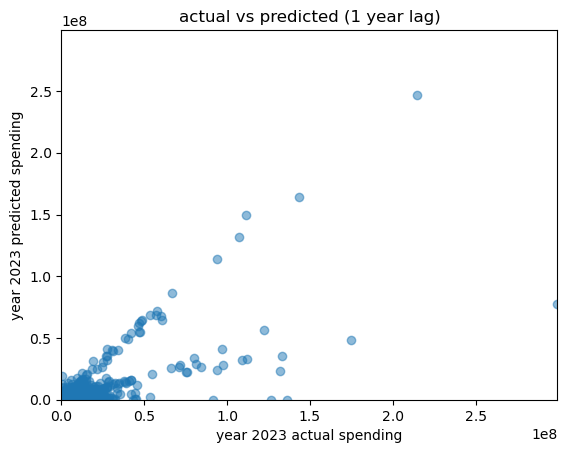

In [137]:
result = check_model(feature_cols,df,'Log_Tot_Mdcr_Pymt_Amt_current')

In [138]:
CHECK_MODEL_DF = pd.read_csv(f'{path}/Modeling/Check_Models_11_4.csv')
CHECK_MODEL_DF = pd.concat([CHECK_MODEL_DF,result],ignore_index=True)
CHECK_MODEL_DF = CHECK_MODEL_DF.drop_duplicates()
CHECK_MODEL_DF

,log,features,malr,mlr,R2(log),R2
0,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O",0.422747,0.169263,NaN,0.817296
1,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.404265,0.020639,0.800698,0.647550
2,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.423558,0.167956,NaN,0.817301
3,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401073,0.028755,0.802116,0.628178
4,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401681,0.033198,0.802663,0.606918
5,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401788,0.033433,0.803000,0.594017


In [139]:
CHECK_MODEL_DF.to_csv(f'{path}/Modeling/Check_Models_11_4.csv',index=False)

# Regression on 'Tot_Mdcr_Pymt_Amt_current'

In [22]:
all_features = [c for c in df.columns if c not in ['Tot_Mdcr_Pymt_Amt_current','Log_Tot_Mdcr_Pymt_Amt_current','Rndrng_NPI','Is_Covid']]

In [167]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/results_11_4.csv')
RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False)
#RESULT_DF.sort_values('malr')

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr
868,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",8,0.480145,0.287687,0.930565,0.443915,0.218355,8.819681e-01,0.546309,...,0.428084,0.063801,0.869404,0.454666,0.220208,0.902357,0.470624,0.236342,0.894474,0.236342
862,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",8,0.480962,0.286705,0.930565,0.444051,0.218352,8.819681e-01,0.545662,...,0.427093,0.064712,0.869404,0.456639,0.218561,0.902357,0.470881,0.236203,0.894474,0.236203
872,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",8,0.480254,0.287749,0.930565,0.443805,0.218421,8.819680e-01,0.545815,...,0.427750,0.063884,0.869404,0.454865,0.219713,0.902357,0.470498,0.236367,0.894474,0.236367
867,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",8,0.481239,0.285384,0.930565,0.443161,0.217692,8.819682e-01,0.546228,...,0.428182,0.062190,0.869403,0.455359,0.218328,0.902358,0.470834,0.234724,0.894474,0.234724
873,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",8,0.480254,0.287748,0.930565,0.443811,0.218426,8.819680e-01,0.545822,...,0.427761,0.063869,0.869404,0.454868,0.219700,0.902357,0.470503,0.236360,0.894474,0.236360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,N,state_Military,1,1.463589,1.123252,-0.000002,1.458727,1.115779,-4.227451e-07,1.559093,...,1.426129,1.094580,-0.000006,1.479375,1.171978,-0.000025,1.477383,1.154909,-0.000051,1.154909
116,N,state_Unknown,1,1.463600,1.123262,-0.000002,1.458702,1.115677,-1.309615e-06,1.559108,...,1.426143,1.094600,-0.000007,1.479394,1.172007,-0.000026,1.477389,1.154906,-0.000052,1.154906
91,N,Type_UnknownOther,1,1.463684,1.123363,-0.000010,1.458758,1.115829,-2.287825e-06,1.559100,...,1.426122,1.094573,-0.000006,1.479370,1.171981,-0.000025,1.477407,1.154945,-0.000053,1.154945
107,N,PharmacyNutrition_Tot_Risk_2,1,1.461027,1.120712,0.000020,1.455421,1.112295,-6.382265e-05,1.557475,...,1.425118,1.093645,-0.000027,1.478348,1.171054,-0.000029,1.475478,1.153061,-0.000072,1.153061


In [168]:
pre_best = RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False).iat[0,1].split(',')
remaining_features = [c for c in all_features if c not in pre_best and c!='Is_Covid']
pre_best

['Tot_Mdcr_Pymt_Amt',
 'LabPathology_Tot_Risk_0',
 'Cd_O',
 'state_West',
 'PrimaryCare_Tot_Risk_1',
 'Type_AcuteCare',
 'state_Territory',
 'PharmacyNutrition_Tot_Risk_1']

In [93]:
start = 0
interrupt = 0

In [165]:
#for i in range(start,len(all_features)):
for i in range(start,len(remaining_features)):
    #c = all_features[i]
    c = remaining_features[i]
    interrupt = i
    try:
        #result = walkforward_LR([c],df,'Tot_Mdcr_Pymt_Amt_current')
        result = walkforward_LR(pre_best+[c],df,'Tot_Mdcr_Pymt_Amt_current')
        RESULT_DF = pd.concat([RESULT_DF, result], ignore_index=True)
    except ValueError: 
        continue

Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O,state_West,PrimaryCare_Tot_Risk_1,Type_AcuteCare,state_Territory,Tot_HCPCS_Cds
  log                                           features  num_features  \
0   N  Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...             8   

   mlr_2018  malr_2018   R2_2018  mlr_2019  malr_2019   R2_2019  mlr_2020  \
0  0.122285   0.440823  0.930272  0.098922    0.42155  0.881871  0.314797   

   ...  mlr_2021  malr_2021   R2_2021  mlr_2022  malr_2022   R2_2022  \
0  ... -0.054196   0.431193  0.869236  0.156738   0.445883  0.902325   

        mlr      malr        R2   abs_mlr  
0  0.127709  0.451047  0.894372  0.127709  

[1 rows x 22 columns]
Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O,state_West,PrimaryCare_Tot_Risk_1,Type_AcuteCare,state_Territory,Tot_Benes
  log                                           features  num_features  \
0   N  Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...             8   

   mlr_2018  malr_2018   R2_2018  mlr_2019 

In [96]:
RESULT_DF[RESULT_DF['log']=='N']

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr
62,N,Tot_HCPCS_Cds,1,1.132206,0.378851,0.042400,1.178477,0.295186,0.038345,1.265461,...,1.141695,0.303524,0.035166,1.177633,0.343986,0.034872,1.179094,0.352065,0.038197,0.352065
63,N,Tot_Benes,1,1.152556,0.895805,0.607260,1.143929,0.879482,0.500861,1.258406,...,1.099792,0.813359,0.457279,1.190531,0.938713,0.403329,1.169043,0.913907,0.499369,0.913907
64,N,Tot_Srvcs,1,1.207551,0.936441,0.497666,1.204830,0.929748,0.232944,1.324102,...,1.215261,0.935153,0.231916,1.279226,1.031124,0.270656,1.246194,0.987735,0.261798,0.987735
65,N,Tot_Sbmtd_Chrg,1,0.875875,0.679510,0.742798,0.870744,0.669526,0.639983,0.983962,...,0.855103,0.598334,0.591998,0.907792,0.716784,0.621900,0.898695,0.701364,0.649245,0.701364
66,N,Tot_Mdcr_Alowd_Amt,1,2.797092,-2.556832,0.912974,2.481691,-2.267335,0.870416,2.692857,...,3.537355,-3.380935,0.847260,2.682812,-2.412679,0.897545,2.838361,-2.583805,0.881500,2.583805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",4,0.892291,-0.402027,0.930294,0.561744,-0.082402,0.881943,0.532828,...,0.489785,-0.146517,0.869303,0.440550,0.214700,0.902352,0.583440,-0.033047,0.894393,0.033047
480,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",4,0.994029,-0.510715,0.930254,0.644050,-0.183963,0.881952,0.647124,...,0.602942,-0.264060,0.869298,0.432073,0.194528,0.902347,0.664044,-0.133167,0.894379,0.133167
481,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",4,1.086984,-0.629959,0.930246,0.642052,-0.194358,0.881954,0.638760,...,0.659990,-0.333451,0.869300,0.435428,0.202918,0.902349,0.692643,-0.171864,0.894380,0.171864
482,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",4,1.024849,-0.570907,0.930248,0.625774,-0.181127,0.881954,0.655534,...,0.624207,-0.300393,0.869297,0.434183,0.200032,0.902348,0.672909,-0.155517,0.894379,0.155517


In [166]:
RESULT_DF.to_csv(f'{path}/Modeling/results_11_4.csv',index=False)

## check on model

In [169]:
feature_cols = RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False).iat[0,1].split(',')
feature_cols

['Tot_Mdcr_Pymt_Amt',
 'LabPathology_Tot_Risk_0',
 'Cd_O',
 'state_West',
 'PrimaryCare_Tot_Risk_1',
 'Type_AcuteCare',
 'state_Territory',
 'PharmacyNutrition_Tot_Risk_1']

                                OLS Regression Results                               
Dep. Variable:     Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.893
Model:                                   OLS   Adj. R-squared:                  0.893
Method:                        Least Squares   F-statistic:                 9.418e+06
Date:                       Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                               17:51:15   Log-Likelihood:            -1.2340e+08
No. Observations:                    9061686   AIC:                         2.468e+08
Df Residuals:                        9061677   BIC:                         2.468e+08
Df Model:                                  8                                         
Covariance Type:                   nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

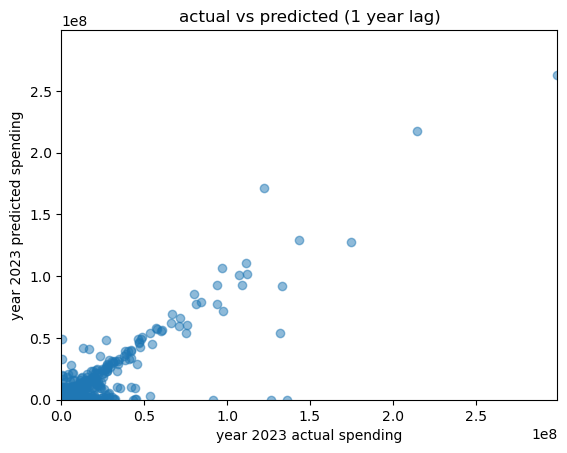

In [170]:
result = check_model(feature_cols,df,'Tot_Mdcr_Pymt_Amt_current')

In [171]:
CHECK_MODEL_DF = pd.read_csv(f'{path}/Modeling/Check_Models_11_4.csv')
CHECK_MODEL_DF = pd.concat([CHECK_MODEL_DF,result],ignore_index=True)
CHECK_MODEL_DF = CHECK_MODEL_DF.drop_duplicates()
CHECK_MODEL_DF

,log,features,malr,mlr,R2(log),R2
0,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O",0.422747,0.169263,NaN,0.817296
1,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.404265,0.020639,0.800698,0.647550
2,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.423558,0.167956,NaN,0.817301
3,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401073,0.028755,0.802116,0.628178
4,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401681,0.033198,0.802663,0.606918
5,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401788,0.033433,0.803000,0.594017
6,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.427668,0.174100,NaN,0.817301
7,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.429154,0.175158,NaN,0.817303
8,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.434767,0.169742,NaN,0.817302


In [172]:
CHECK_MODEL_DF.to_csv(f'{path}/Modeling/Check_Models_11_4.csv',index=False)